# Project 2: Exploratory Data Analysis (EDA) Report
---
## Assigned Topic:
__Wind Turbines__

## Selected Problem Statement: 
__A private equity firm focused on renewable energy aims to acquire U.S. wind farms but requires deeper insight into the specific structural characteristics and geographic locations that drive peak energy efficiency. To guide these acquisitions, the Investment Committee must evaluate historical Net Generation (MWh) data across various Census Regions, segmented by turbine specifications and technical details. By spotting niche opportunities, distinguishing the physical configurations and regions with the strongest historical performance, the firm can strategically target assets that meet proven benchmarks for high energy output.__

## 1. Introduction & Objectives

### 1.1 Context & Background
Wind energy is a major and growing source of renewable electricity in the U.S., with tens of thousands of turbines installed nationwide. Private equity firms often invest in wind farms, but returns depend heavily on location — specifically, turbine size, local wind strength, and electricity prices. This project analyzes wind turbines across the four U.S. Census Regions to find the best region for a new wind farm investment.
### 1.2 Core Analytical Objectives
* Which Census Region has the most installed wind capacity and highest estimated Net Generation?
* How do physical turbine specifications (like rotor diameter and hub height) impact energy output?
* Is there a trade-off between regional wind speeds and local electricity rates?
* Overall, which region and turbine design represent the best target for a new investment?
---

## 2. Environment Setup & Data Collection
*(Rubric Checkpoint: Ensure all modules are imported cleanly with appropriate standard aliases. Data files must be loaded using relative paths for replicability.)*

In [242]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import missingno as msno

In [243]:
# Load data using strictly relative file paths
wind_turbines=pd.read_csv('../Data/wind-turbines.csv', encoding='latin-1')
wind_speed = pd.read_csv('../Data/extra/windiest-states-in-the-us.-2025.csv')
rates = pd.read_csv('../Data/extra/average_electricity_rates.csv')
bills = pd.read_csv('../Data/extra/average_electricity_bills.csv')

# create a working copy so the original stays untouched as a reference
wt_copy = wind_turbines.copy()

---
## 3. Data Handling


### 3.1 get the number of features and records, missing values and data types

In [244]:
wind_turbines.info()

<class 'pandas.DataFrame'>
RangeIndex: 70808 entries, 0 to 70807
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   case_id        70808 non-null  int64  
 1   faa_ors        65016 non-null  str    
 2   faa_asn        65686 non-null  str    
 3   usgs_pr_id     38263 non-null  float64
 4   eia_id         65015 non-null  float64
 5   t_state        70808 non-null  str    
 6   t_county       70808 non-null  str    
 7   t_fips         70808 non-null  int64  
 8   p_name         70808 non-null  str    
 9   p_year         70195 non-null  float64
 10  p_tnum         70808 non-null  int64  
 11  p_cap          66326 non-null  float64
 12  t_manu         65168 non-null  str    
 13  t_model        65031 non-null  str    
 14  t_cap          65328 non-null  float64
 15  t_hh           64628 non-null  float64
 16  t_rd           64874 non-null  float64
 17  t_rsa          64874 non-null  float64
 18  t_ttlh         64

### 3.2 Examine the sum of missing values in each column.

In [245]:
wind_turbines.isnull().sum().sort_values(ascending=False)


retrofit_year    64822
usgs_pr_id       32545
t_img_date        8316
t_hh              6180
t_ttlh            6180
t_rd              5934
t_rsa             5934
eia_id            5793
faa_ors           5792
t_model           5777
t_manu            5640
t_cap             5480
faa_asn           5122
p_cap             4482
p_year             613
t_state              0
case_id              0
t_fips               0
t_county             0
p_tnum               0
p_name               0
t_conf_atr           0
retrofit             0
t_conf_loc           0
t_img_srce           0
xlong                0
ylat                 0
dtype: int64

### 3.3 preview the first 5 rows of the data.

In [246]:
wind_turbines.head()

,case_id,faa_ors,faa_asn,usgs_pr_id,eia_id,t_state,t_county,t_fips,p_name,p_year,...,t_rsa,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,t_img_date,t_img_srce,xlong,ylat
0,3072661,NaN,NaN,5149.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.363762,35.077908
1,3072695,NaN,NaN,5143.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.364410,35.077435
2,3072704,NaN,NaN,5146.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.364197,35.077644
3,3063272,19-028134,2014-WTE-4084-OE,NaN,NaN,IA,Story County,19169,30 MW Iowa DG Portfolio,2017.0,...,12271.85,150.0,0,NaN,3,3,4/24/2017,Digital Globe,-93.430367,42.028233
4,3053390,19-028015,2015-WTE-6386-OE,NaN,NaN,IA,Boone County,19015,30 MW Iowa DG Portfolio,2017.0,...,12271.85,150.0,0,NaN,3,3,6/1/2017,Digital Globe,-93.700424,41.977608


In [247]:
# check duplicate rows (entire row)
wind_turbines.duplicated().sum()

np.int64(0)

### 3.4 Define function to map states to Census Regions

In [248]:
def get_census_region(state_code):
    northeast = ['ME', 'NH', 'VT', 'MA', 'RI', 'CT', 'NY', 'PA', 'NJ']
    midwest = ['WI', 'MI', 'IL', 'IN', 'OH', 'ND', 'SD', 'NE', 'KS', 'MN', 'IA', 'MO']
    south = ['DE', 'MD', 'VA', 'WV', 'KY', 'NC', 'SC', 'GA', 'FL', 'AL', 'TN', 'MS', 'AR', 'LA', 'OK', 'TX']
    west = ['ID', 'MT', 'WY', 'NV', 'UT', 'CO', 'AZ', 'NM', 'WA', 'OR', 'CA', 'AK', 'HI']
    
    if state_code in northeast:
        return 'Northeast'
    elif state_code in midwest:
        return 'Midwest'
    elif state_code in south:
        return 'South'
    elif state_code in west:
        return 'West'
    else:
        return 'Other'

# create census_region column and t_cap_mw column by using .apply()
wt_copy['census_region'] = wt_copy['t_state'].apply(get_census_region)
wt_copy.head(3)

,case_id,faa_ors,faa_asn,usgs_pr_id,eia_id,t_state,t_county,t_fips,p_name,p_year,...,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,t_img_date,t_img_srce,xlong,ylat,census_region
0,3072661,NaN,NaN,5149.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.363762,35.077908,West
1,3072695,NaN,NaN,5143.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.364410,35.077435,West
2,3072704,NaN,NaN,5146.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.364197,35.077644,West


### 3.5 Check wind_speed , rates, bills dataset 

In [249]:
wind_speed.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   stateFlagCode                      0 non-null      float64
 1   state                              50 non-null     str    
 2   WindiestStatesAverageWindSpeedMPH  50 non-null     float64
 3   MeanWindSpeed328ft                 50 non-null     float64
 4   MeanWindPower328ft                 50 non-null     int64  
 5   MeanWindSpeed33ft                  50 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.9 KB


In [250]:
wind_speed.isnull().sum()


stateFlagCode                        50
state                                 0
WindiestStatesAverageWindSpeedMPH     0
MeanWindSpeed328ft                    0
MeanWindPower328ft                    0
MeanWindSpeed33ft                     0
dtype: int64

In [251]:
wind_speed.head()


,stateFlagCode,state,WindiestStatesAverageWindSpeedMPH,MeanWindSpeed328ft,MeanWindPower328ft,MeanWindSpeed33ft
0,NaN,South Dakota,21.32,20.3,722,12.8
1,NaN,Montana,21.03,20.5,985,13.5
2,NaN,Wyoming,20.88,21.5,964,14.1
3,NaN,Idaho,20.59,16.5,472,10.6
4,NaN,Colorado,20.16,20.0,751,12.8


In [252]:
wind_speed.duplicated().sum()


np.int64(0)

In [253]:
# drop stateFlagCode - entirely empty, no analytical value
wind_speed = wind_speed.drop(columns=['stateFlagCode'])

In [254]:
rates.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   State        51 non-null     str    
 1   Residential  51 non-null     float64
 2   Commercial   51 non-null     float64
 3   Average      51 non-null     float64
dtypes: float64(3), str(1)
memory usage: 2.2 KB


In [255]:
rates.isnull().sum()

State          0
Residential    0
Commercial     0
Average        0
dtype: int64

In [256]:
rates.head()

,State,Residential,Commercial,Average
0,Alabama,14.91,13.83,14.37
1,Alaska,22.38,18.43,20.41
2,Arizona,15.20,11.92,13.56
3,Arkansas,11.74,10.11,10.93
4,California,30.55,23.13,26.84


In [257]:
rates.duplicated().sum()

np.int64(0)

In [258]:
bills.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   State        50 non-null     str    
 1   Residential  50 non-null     float64
 2   Commercial   50 non-null     str    
 3   Average      50 non-null     str    
dtypes: float64(1), str(3)
memory usage: 2.7 KB


In [259]:
bills.isnull().sum()

State          0
Residential    0
Commercial     0
Average        0
dtype: int64

In [260]:
bills.head(15)


,State,Residential,Commercial,Average
0,Alabama,115.00,679.26,397.13
1,Alaska,198.10,"1,201.93",700.02
2,Arizona,118.76,645.96,382.36
3,Arkansas,101.92,577.55,339.74
4,California,258.38,"1,400.90",829.64
5,Colorado,122.52,670.78,396.65
6,Connecticut,223.50,"1,194.65",709.07
7,Delaware,124.49,662.19,393.34
8,Florida,126.37,704.03,415.2
9,Georgia,116.88,659.27,388.07


In [261]:
# fix comma-separated numbers in Commercial and Average columns before converting to numeric
for col in ['Commercial', 'Average']:
    bills[col] = bills[col].astype(str).str.replace(',', '', regex=False)
    bills[col] = pd.to_numeric(bills[col], errors='coerce')

# confirm the fix worked - dtypes should now all be float64
bills.dtypes

State              str
Residential    float64
Commercial     float64
Average        float64
dtype: object

In [262]:
# wind_speed/elec_rates/elec_bills use full state names, wt_copy uses 2-letter abbreviations (t_state)

us_state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA','Colorado':'CO',
    'Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID',
    'Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY','Louisiana':'LA',
    'Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
    'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ',
    'New Mexico':'NM','New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
    'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD',
    'Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA',
    'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY','District of Columbia':'DC'}

wind_speed['state'] = wind_speed['state'].str.strip().map(us_state_abbrev)
rates['State'] = rates['State'].str.strip().map(us_state_abbrev)
bills['State'] = bills['State'].str.strip().map(us_state_abbrev)


In [263]:
# Build clean subsets with clear column names

wind_speed_clean = wind_speed[['state', 'WindiestStatesAverageWindSpeedMPH', 'MeanWindSpeed328ft', 'MeanWindPower328ft', 'MeanWindSpeed33ft']].rename(
    columns={'WindiestStatesAverageWindSpeedMPH': 'avg_wind_speed_mph',
             'MeanWindSpeed328ft': 'wind_speed_328ft',
             'MeanWindPower328ft': 'wind_power_328ft',
             'MeanWindSpeed33ft': 'wind_speed_33ft'}
)

rates_clean = rates[['State', 'Residential', 'Commercial', 'Average']].rename(
    columns={'Residential': 'rate_residential', 'Commercial': 'rate_commercial', 'Average': 'rate_average'}
)

bills_clean = bills[['State', 'Residential', 'Commercial', 'Average']].rename(
    columns={'Residential': 'bill_residential', 'Commercial': 'bill_commercial', 'Average': 'bill_average'}
)

In [264]:
# Merge everything onto wt_copy

wt_copy = pd.merge(left=wt_copy, right=wind_speed_clean, left_on='t_state',right_on='state',  how='left')
wt_copy = pd.merge(left=wt_copy, right=rates_clean, left_on='t_state',right_on='State',  how='left')
wt_copy = pd.merge(left=wt_copy, right=bills_clean, left_on='t_state',right_on='State',  how='left')
wt_copy.head(3)

,case_id,faa_ors,faa_asn,usgs_pr_id,eia_id,t_state,t_county,t_fips,p_name,p_year,...,wind_power_328ft,wind_speed_33ft,State_x,rate_residential,rate_commercial,rate_average,State_y,bill_residential,bill_commercial,bill_average
0,3072661,NaN,NaN,5149.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,649.0,10.7,CA,30.55,23.13,26.84,CA,258.38,1400.9,829.64
1,3072695,NaN,NaN,5143.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,649.0,10.7,CA,30.55,23.13,26.84,CA,258.38,1400.9,829.64
2,3072704,NaN,NaN,5146.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,649.0,10.7,CA,30.55,23.13,26.84,CA,258.38,1400.9,829.64


In [265]:
# check which states didn't get matched to any of the 4 census regions
wt_copy[wt_copy['census_region'] == 'Other']['t_state'].unique()

<ArrowStringArray>
['PR', 'GU']
Length: 2, dtype: str

In [266]:
# Drop territories not covered by census regions (PR, GU)

wt_copy = wt_copy[~wt_copy['t_state'].isin(['PR', 'GU'])]

In [267]:
# Merge validation
wt_copy.isnull().sum()



case_id                   0
faa_ors                5728
faa_asn                5107
usgs_pr_id            32481
eia_id                 5789
t_state                   0
t_county                  0
t_fips                    0
p_name                    0
p_year                  611
p_tnum                    0
p_cap                  4481
t_manu                 5637
t_model                5774
t_cap                  5479
t_hh                   6179
t_rd                   5933
t_rsa                  5933
t_ttlh                 6179
retrofit                  0
retrofit_year         64758
t_conf_atr                0
t_conf_loc                0
t_img_date             8316
t_img_srce                0
xlong                     0
ylat                      0
census_region             0
state                     0
avg_wind_speed_mph        0
wind_speed_328ft          0
wind_power_328ft          0
wind_speed_33ft           0
State_x                   0
rate_residential          0
rate_commercial     

In [268]:
#drop duplicated columns after merging)
wt_copy = wt_copy.drop(columns=['state', 'State_x', 'State_y' ], errors='ignore')


In [269]:
# drop columns with no analytical value for this project (external reference IDs + image metadata)
cols_to_drop = ['faa_ors', 'faa_asn', 'usgs_pr_id', 'eia_id', 't_img_date', 't_img_srce']
wt_copy = wt_copy.drop(columns=cols_to_drop)


In [270]:
wt_copy.duplicated().sum()

np.int64(0)

In [271]:
wt_copy['census_region'].value_counts()


census_region
Midwest      26716
South        22962
West         18416
Northeast     2650
Name: count, dtype: int64

In [272]:
# show ALL unique manufacturer names with counts

pd.set_option('display.max_rows', None)
print(wt_copy['t_manu'].value_counts())
pd.reset_option('display.max_rows')

t_manu
GE Wind                                                                     29137
Vestas                                                                      16246
Siemens                                                                      4991
Gamesa                                                                       3077
Mitsubishi                                                                   2620
Siemens Gamesa Renewable Energy                                              2043
Nordex                                                                       1591
Suzlon                                                                       1316
Acciona                                                                       758
REpower                                                                       574
NEG Micon                                                                     529
Enron                                                                         396
Bonus    

In [273]:
map_manu = {
    'Gamesa': 'Siemens',
    'Siemens Gamesa Renewable Energy': 'Siemens',
    'Bonus': 'Siemens',
    'Goldwind Americas': 'Goldwind',
    'NEG Micon': 'Micon',
    'REpower': 'Suzlon',
    'Alstom': 'GE Wind',
    'Zond': 'GE Wind',
    'Enron': 'GE Wind'
}

wt_copy['t_manu'] = wt_copy['t_manu'].str.strip().replace(map_manu)

In [274]:
wt_copy.isnull().sum()

case_id                   0
t_state                   0
t_county                  0
t_fips                    0
p_name                    0
p_year                  611
p_tnum                    0
p_cap                  4481
t_manu                 5637
t_model                5774
t_cap                  5479
t_hh                   6179
t_rd                   5933
t_rsa                  5933
t_ttlh                 6179
retrofit                  0
retrofit_year         64758
t_conf_atr                0
t_conf_loc                0
xlong                     0
ylat                      0
census_region             0
avg_wind_speed_mph        0
wind_speed_328ft          0
wind_power_328ft          0
wind_speed_33ft           0
rate_residential          0
rate_commercial           0
rate_average              0
bill_residential          0
bill_commercial           0
bill_average              0
dtype: int64

In [275]:
key_cols = ['t_cap', 't_hh', 't_rd', 't_rsa', 't_ttlh', 'p_cap']
missing_pct = (wt_copy[key_cols].isnull().mean() * 100).round(2)
print(missing_pct)

t_cap     7.74
t_hh      8.73
t_rd      8.39
t_rsa     8.39
t_ttlh    8.73
p_cap     6.33
dtype: float64


<Axes: >

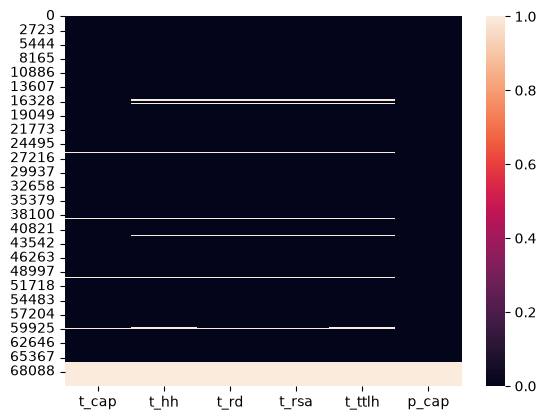

In [276]:
sns.heatmap(wt_copy[key_cols].isnull())


Text(0.5, 1.0, 'Correlation of Missingness Between Columns')

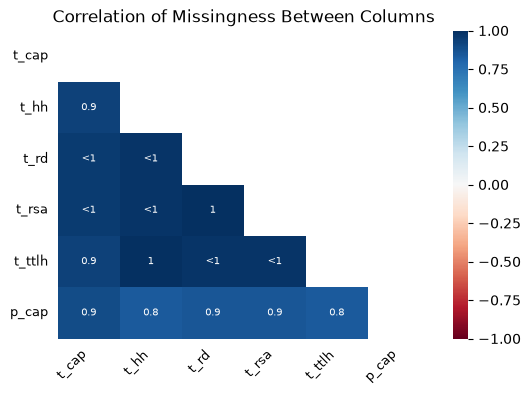

In [277]:
msno.heatmap(wt_copy[key_cols], figsize=(6,4), fontsize= 9)
plt.title('Correlation of Missingness Between Columns')

In [278]:
# drop rows missing key physical spec columns (t_cap, t_hh, t_rd, t_rsa, t_ttlh, p_cap)
# these values can't be reliably estimated/imputed since they represent actual physical 
# turbine specs, and missing rows are a small % of the data (<9% per column, <1.1% after 
# removing fully-empty rows), so dropping them has minimal impact on the analysis

wt_copy = wt_copy.dropna(subset=key_cols)
wt_copy[key_cols].isnull().sum()


t_cap     0
t_hh      0
t_rd      0
t_rsa     0
t_ttlh    0
p_cap     0
dtype: int64

In [279]:
# convert turbine rated capacity from kW to MW
wt_copy['t_cap_mw'] = wt_copy['t_cap'] / 1000.0

In [280]:
BASE_CAPACITY_FACTOR = 0.346   # US national average capacity factor (DOE/EPA, 2023)

national_avg_wind_power = wt_copy['wind_power_328ft'].mean()

wt_copy['capacity_factor_est'] = BASE_CAPACITY_FACTOR * (wt_copy['wind_power_328ft'] / national_avg_wind_power)
wt_copy['capacity_factor_est'] = wt_copy['capacity_factor_est'].clip(upper=0.50)  # realistic cap, turbines don't exceed ~50% CF

wt_copy['net_gen_mwh'] = wt_copy['t_cap_mw'] * wt_copy['capacity_factor_est'] * 8760

wt_copy.head()

,case_id,t_state,t_county,t_fips,p_name,p_year,p_tnum,p_cap,t_manu,t_model,...,wind_speed_33ft,rate_residential,rate_commercial,rate_average,bill_residential,bill_commercial,bill_average,t_cap_mw,capacity_factor_est,net_gen_mwh
3,3063272,IA,Story County,19169,30 MW Iowa DG Portfolio,2017.0,10,30.0,Nordex,AW125/3000,...,11.1,12.43,10.19,11.31,108.33,594.72,351.53,3.0,0.302741,7956.046075
4,3053390,IA,Boone County,19015,30 MW Iowa DG Portfolio,2017.0,10,30.0,Nordex,AW125/3000,...,11.1,12.43,10.19,11.31,108.33,594.72,351.53,3.0,0.302741,7956.046075
5,3063269,IA,Story County,19169,30 MW Iowa DG Portfolio,2017.0,10,30.0,Nordex,AW125/3000,...,11.1,12.43,10.19,11.31,108.33,594.72,351.53,3.0,0.302741,7956.046075
6,3049500,IA,Story County,19169,30 MW Iowa DG Portfolio,2017.0,10,30.0,Nordex,AW125/3000,...,11.1,12.43,10.19,11.31,108.33,594.72,351.53,3.0,0.302741,7956.046075
7,3049502,IA,Story County,19169,30 MW Iowa DG Portfolio,2017.0,10,30.0,Nordex,AW125/3000,...,11.1,12.43,10.19,11.31,108.33,594.72,351.53,3.0,0.302741,7956.046075


In [281]:
numeric_cols = ['t_cap', 't_hh', 't_rd', 'net_gen_mwh']
wt_copy[numeric_cols].describe()


,t_cap,t_hh,t_rd,net_gen_mwh
count,64562.000000,64562.000000,64562.000000,64562.000000
mean,1982.281977,81.061085,95.938097,5963.443466
std,695.590614,12.024376,22.992090,2340.581271
min,50.000000,22.800000,14.000000,119.878923
25%,1500.000000,80.000000,82.000000,4475.153592
50%,2000.000000,80.000000,100.000000,5754.335096
75%,2300.000000,87.000000,110.000000,6889.368311
max,6000.000000,131.000000,155.000000,18834.000000


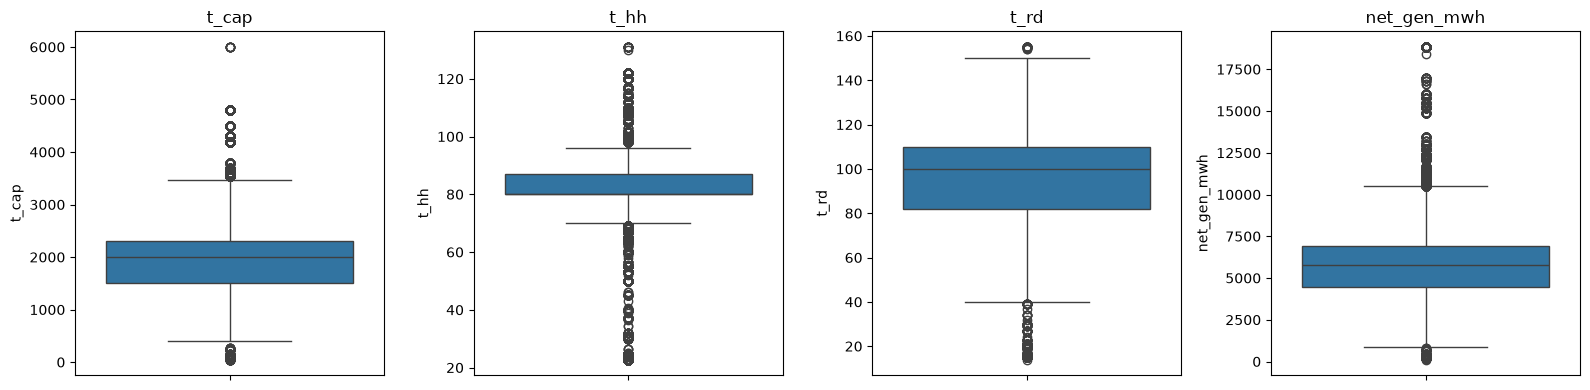

In [282]:

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=wt_copy[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [283]:
# save the final cleaned dataset 
wt_copy.to_csv('../Data/wind_turbines_clean.csv', index=False)


---
## 4. Exploratory Data Analysis (EDA)
*(Rubric Checkpoint: Demonstrate mastery of basic descriptive statistics, sorting records, and applying Boolean masking techniques to isolate specific baseline metrics.)*

### 4.1 Aggregating Key Metrics by Census Region

In [284]:
region_summary = wt_copy.groupby('census_region').agg(
    total_turbines=('case_id', 'count'),
    total_capacity_mw=('t_cap_mw', 'sum'),
    median_capacity_mw=('t_cap_mw', 'median'),
    median_hub_height=('t_hh', 'median'),
    median_rotor_diameter=('t_rd', 'median'),
    avg_wind_speed=('avg_wind_speed_mph', 'mean'),
    avg_electricity_rate=('rate_average', 'mean'),
    avg_electricity_bill=('bill_average', 'mean'),
    median_net_generation_mwh=('net_gen_mwh', 'median'),
    total_net_generation_mwh=('net_gen_mwh', 'sum'),
    median_wind_power=('wind_power_328ft', 'median')

).reset_index()

region_summary

,census_region,total_turbines,total_capacity_mw,median_capacity_mw,median_hub_height,median_rotor_diameter,avg_wind_speed,avg_electricity_rate,avg_electricity_bill,median_net_generation_mwh,total_net_generation_mwh,median_wind_power
0,Midwest,25063,50090.010,2.00,80.0,100.0,18.539400,12.091133,366.885281,5756.145512,1.514221e+08,592.0
1,Northeast,2592,5109.550,1.65,80.0,83.0,16.436370,19.893530,564.739699,5174.365759,1.510599e+07,631.0
2,South,21838,45537.739,2.00,80.0,100.0,15.825460,11.687686,331.774463,5681.282348,1.294747e+08,553.0
3,West,15069,27242.790,1.80,80.0,90.0,17.126513,15.849151,480.039272,5885.810470,8.900911e+07,649.0


### 4.2 Ranking Regions by Wind Speed, Electricity Rate, and Net Generation

In [285]:
# sort by wind speed to see ranking
region_summary.sort_values('avg_wind_speed', ascending=False)[['census_region', 'avg_wind_speed']]


,census_region,avg_wind_speed
0,Midwest,18.539400
3,West,17.126513
1,Northeast,16.436370
2,South,15.825460


In [286]:
# sort by electricity rate to see ranking
region_summary.sort_values('avg_electricity_rate', ascending=False)[['census_region', 'avg_electricity_rate']]

,census_region,avg_electricity_rate
1,Northeast,19.893530
3,West,15.849151
0,Midwest,12.091133
2,South,11.687686


In [287]:
# sort by net generation to see which region actually produces the most estimated energy
region_summary.sort_values('median_net_generation_mwh', ascending=False)[['census_region', 'median_net_generation_mwh', 'total_net_generation_mwh']]

,census_region,median_net_generation_mwh,total_net_generation_mwh
3,West,5885.810470,8.900911e+07
0,Midwest,5756.145512,1.514221e+08
2,South,5681.282348,1.294747e+08
1,Northeast,5174.365759,1.510599e+07


### 4.3. Key Visualizations

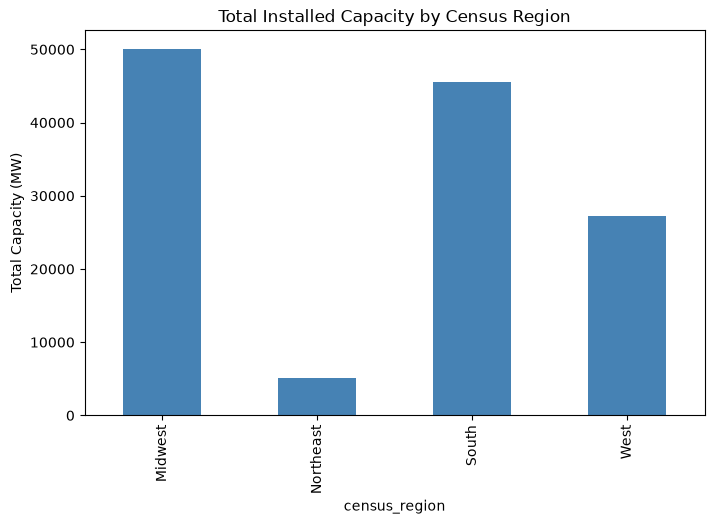

In [288]:
# Visualization 1: Total Installed Capacity by Census Region

region_summary.plot(x='census_region',
                    y='total_capacity_mw',
                    kind='bar', figsize=(8,5), legend=False, color='steelblue' ,
                    title= 'Total Installed Capacity by Census Region',
                   ylabel='Total Capacity (MW)')

plt.savefig('../Presentation/images/viz1_total_capacity.png', dpi=150, bbox_inches='tight')

plt.show()

**Visualization 1 Interpretation:**
> This chart shows the Midwest has the largest total installed wind capacity (~50,100 MW), 
> closely followed by the South (~45,500 MW). The Northeast has by far the smallest footprint 
> (~5,100 MW), while the West falls in the middle (~27,400 MW).

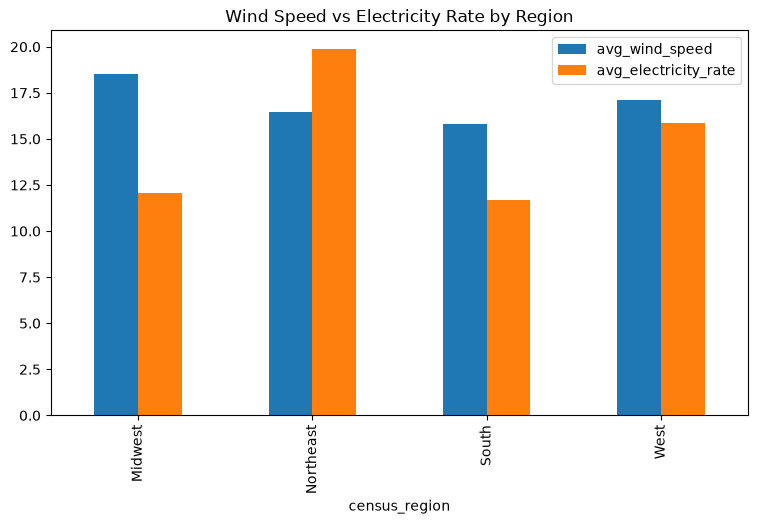

In [289]:
# Visualization 2: Wind Speed vs Electricity Rate by Region

region_summary.plot(x='census_region', y=['avg_wind_speed', 'avg_electricity_rate'], kind='bar', figsize=(9,5), title='Wind Speed vs Electricity Rate by Region')

plt.savefig('../Presentation/images/viz2_wind_vs_rate.png', dpi=150, bbox_inches='tight')

plt.show()

**Visualization 2 Interpretation:**
 > This chart shows a trade-off: the Midwest has the strongest wind but a lower electricity 
> rate, while the Northeast has the highest rate but the weakest wind. So the best region 
> depends on balancing both wind speed and electricity price together, not just one factor.

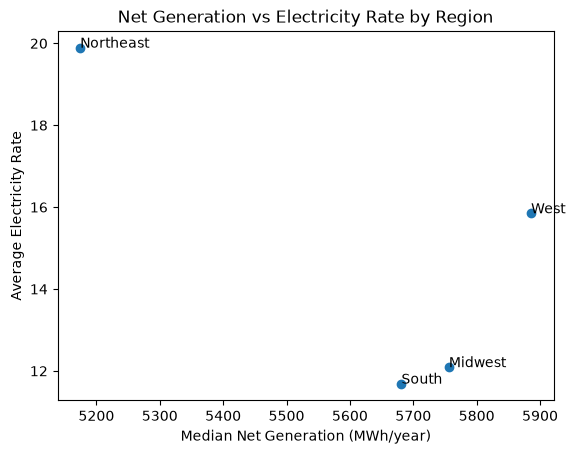

In [290]:
# Visualization 3: Net Generation vs Electricity Rate (Combined View)
plt.scatter(region_summary['median_net_generation_mwh'], region_summary['avg_electricity_rate'])

# add region name next to each point
for i, row in region_summary.iterrows():
    plt.text(row['median_net_generation_mwh'], row['avg_electricity_rate'], row['census_region'])

plt.xlabel('Median Net Generation (MWh/year)')
plt.ylabel('Average Electricity Rate')
plt.title('Net Generation vs Electricity Rate by Region')

plt.savefig('../Presentation/images/viz3_scatter_netgen_vs_rate.png', dpi=150, bbox_inches='tight')
plt.show()

**Visualization 3 Interpretation:**
> This scatter plot shows Net Generation against electricity rate. The Northeast is the clear loser here — lowest net generation AND highest electricity rate. Midwest and South look like the best combo: strong net generation with the cheapest electricity. West has the highest net generation, but its rate is also on the higher side.

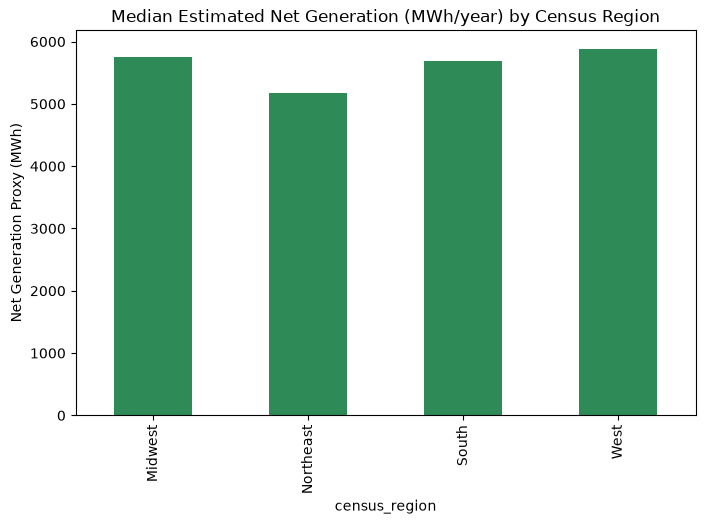

In [291]:
# Visualization: Median Net Generation (MWh) by Census Region
region_summary.plot(x='census_region',
                    y='median_net_generation_mwh',
                    kind='bar', figsize=(8,5), legend=False, color='seagreen',
                    title='Median Estimated Net Generation (MWh/year) by Census Region',
                    ylabel='Net Generation Proxy (MWh)')

plt.savefig('../Presentation/images/viz4_net_generation.png', dpi=150, bbox_inches='tight')
plt.show()

**Visualization 4 Interpretation:**
> This chart shows the median net generation per turbine is actually pretty close across all 4 regions (~5,100-5,900 MWh), way closer than the huge gap we saw in Visualization 1 (Total Capacity). So the regional differences aren't really about how efficient individual turbines are - it's mostly about how many turbines got built. Midwest and South are ahead mainly because of scale, not because their turbines perform better per unit.


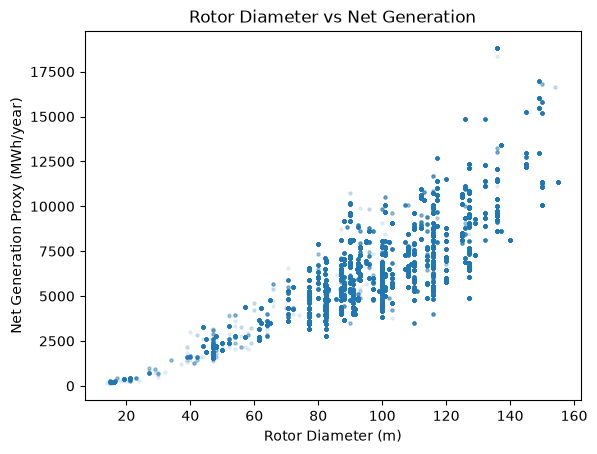

In [292]:
# Visualization 5: Rotor Diameter vs Net Generation
plt.scatter(wt_copy['t_rd'], wt_copy['net_gen_mwh'], alpha=0.1, s=5)

plt.xlabel('Rotor Diameter (m)')
plt.ylabel('Net Generation Proxy (MWh/year)')
plt.title('Rotor Diameter vs Net Generation')

plt.savefig('../Presentation/images/viz5_rotor_vs_netgen.png', dpi=150, bbox_inches='tight')
plt.show()

**Visualization 5 Interpretation:**
> This scatter plot shows a strong positive relationship between rotor diameter and net generation - larger rotors consistently produce more estimated energy. This makes physical sense: a bigger rotor diameter means a larger swept area, which captures more wind and converts it into more power. This is the clearest structural driver of energy output we've found in the data.

#### ---
## 5. Summary of Findings & Actionable Recommendations

### 5.1 Key Insights (Summary of Findings)
- The Midwest has the most installed wind capacity (~50,100 MW) and the strongest average 
  wind speed (18.6 mph) of any region.
- But when we look at median net generation per turbine, all four regions are actually 
  pretty close (~5,100-5,900 MWh/year) - the Midwest's advantage is mostly about scale 
  (number of turbines built), not per-turbine efficiency.
- Rotor diameter is the strongest driver of net generation we found - bigger rotors mean 
  more energy, almost regardless of region.
- The West has the highest median net generation, but the Midwest and South offer the best 
  combination of strong output and low electricity rates.
- The Northeast is the weakest performer overall: lowest net generation, highest electricity 
  rate, and fewest turbines.

### 5.2 Actionable Recommendations
- Prioritize turbine projects with large rotor diameters (100m+) regardless of region - this 
  is the strongest single factor linked to higher energy output.
- The Midwest and South are the strongest regions overall: solid net generation combined 
  with the cheapest electricity rates.
- The West produces the most energy per turbine, but its higher electricity rate makes it a 
  slightly less cost-efficient choice than the Midwest/South.
- Deprioritize the Northeast - weakest wind, most expensive electricity, and lowest turbine 
  count.
  
### 5.3 Limitations & Areas for Further Research
- Actual EIA-923 Net Generation data (MWh) wasn't available, so we built a proxy using 
  turbine capacity and an estimated capacity factor scaled by regional wind power - not 
  the real production numbers.
- Electricity rates used are retail/consumer prices, not necessarily the wholesale price a 
  wind farm would actually be paid for its electricity.
- This analysis compared whole Census Regions - looking at individual states could reveal 
  more specific and precise investment locations.
---

## 6. Data Dictionary & References

### 6.1 Data Dictionary

| Feature / Column | Data Type | Source | Description |
|:---|:---|:---|:---|
| case_id | int | Original | Unique stable ID for each turbine |
| t_state | string | Original | 2-letter state code where turbine is located |
| t_county | string | Original | County where turbine is located |
| t_fips | string | Original | State + county FIPS code |
| p_name | string | Original | Name of the wind power project |
| p_year | float | Original | Year turbine became operational |
| p_tnum | int | Original | Number of turbines in the project |
| p_cap | float | Original | Cumulative capacity of the whole project (MW) |
| t_manu | string | Original (cleaned) | Turbine manufacturer, with duplicate/legacy brand names consolidated (e.g. Gamesa → Siemens) |
| t_model | string | Original | Manufacturer's model name |
| t_cap | float | Original | Rated capacity of a single turbine (kW) |
| t_hh | float | Original | Hub height (m) |
| t_rd | float | Original | Rotor diameter (m) |
| t_rsa | float | Original | Rotor swept area (m²) |
| t_ttlh | float | Original | Total turbine height, ground to blade tip (m) |
| retrofit | int | Original | 0/1 flag - whether turbine was retrofitted |
| retrofit_year | float | Original | Year of retrofit (if applicable) |
| t_conf_atr | int | Original | Confidence score (1-3) for turbine attribute data |
| t_conf_loc | int | Original | Confidence score (1-3) for turbine location data |
| xlong | float | Original | Longitude |
| ylat | float | Original | Latitude |
| census_region | string | Engineered | US Census Region (Northeast/Midwest/South/West), mapped from t_state |
| avg_wind_speed_mph | float | Original (merged) | Average state wind speed (mph) |
| wind_speed_328ft | float | Original (merged) | Mean wind speed at 328ft (m/s) |
| wind_power_328ft | float | Original (merged) | Mean wind power density at 328ft (W/m²) |
| wind_speed_33ft | float | Original (merged) | Mean wind speed at 33ft (m/s) |
| rate_residential | float | Original (merged) | Residential electricity rate (cents/kWh) |
| rate_commercial | float | Original (merged) | Commercial electricity rate (cents/kWh) |
| rate_average | float | Original (merged) | Average electricity rate across sectors (cents/kWh) |
| bill_residential | float | Original (merged) | Average residential electricity bill ($) |
| bill_commercial | float | Original (merged) | Average commercial electricity bill ($) |
| bill_average | float | Original (merged) | Average electricity bill across sectors ($) |
| t_cap_mw | float | Engineered | t_cap converted from kW to MW |
| capacity_factor_est | float | Engineered | Estimated capacity factor, scaled from the US national average (34.6%) by each state's relative wind power density |
| net_gen_mwh | float | Engineered | Estimated annual net generation (MWh/year) - a proxy for actual EIA-923 net generation, calculated as t_cap_mw × capacity_factor_est × 8760 |
### 6.2 References & Sources
* *Source 1:*